# Plot dos casos do artigo (3x2) com $\sigma_x$, $\sigma_y$ e $\sigma_z$ separados

Este notebook é uma versão do `plot_article_all_cases_2x2.ipynb`, mas agora os valores esperados de spin ficam em painéis separados:

- $\langle \sigma_x \rangle$;
- $\langle \sigma_y \rangle$;
- $\langle \sigma_z \rangle$.

Assim, cada figura fica no formato **3x2**:

```text
[ não-classicalidade ] [ g(t)        ]
[ <sigma_x>          ] [ <sigma_y>   ]
[ <sigma_z>          ] [ <N>         ]
```

Ele foi feito para ler os resultados gerados por:

```bash
python expected_values_all_article_cases_with_xy.py
```

Por padrão, ele procura automaticamente a pasta mais recente em:

```text
results/expected_values_all_cases_xy/expected_values_all_cases_xy*
```

Se existir também uma pasta de resultados de não-classicalidade em:

```text
results/article_all_cases/article_all_cases*
```

o primeiro painel mantém a curva de não-classicalidade. Caso contrário, o notebook ainda plota $g(t)$, $\langle \sigma_x \rangle$, $\langle \sigma_y \rangle$, $\langle \sigma_z \rangle$ e $\langle N \rangle$.

In [1]:

import os
import glob
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    "figure.figsize": (12, 8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})



## Configuração

Se quiser, altere manualmente `ROOT_EV` e/ou `ROOT_METRIC`. Se deixar `None`, o notebook pega automaticamente a pasta mais recente.

- `ROOT_EV`: pasta com os valores esperados novos, incluindo `expect_X` e `expect_Y`.
- `ROOT_METRIC`: pasta opcional com as curvas de não-classicalidade do notebook original.
- `INCLUDE_CLOSED`: se `True`, também plota os casos fechados `const`, `var_min`, `var_av`, `var_max`, quando existirem.


In [2]:

def latest_root(base, prefix):
    folders = sorted(glob.glob(os.path.join(base, f"{prefix}*")))
    if not folders:
        raise FileNotFoundError(f"Não encontrei pastas em {base}/{prefix}*")
    return folders[-1]


def try_latest_root(base, prefix):
    folders = sorted(glob.glob(os.path.join(base, f"{prefix}*")))
    return folders[-1] if folders else None


# Resultados gerados por expected_values_all_article_cases_with_xy.py
ROOT_EV = None
if ROOT_EV is None:
    ROOT_EV = latest_root("results/expected_values_all_cases_xy", "expected_values_all_cases_xy")

# Resultados opcionais do notebook/script antigo, usados apenas para o painel de não-classicalidade
ROOT_METRIC = None
if ROOT_METRIC is None:
    ROOT_METRIC = try_latest_root("results/article_all_cases", "article_all_cases")

# False = plota apenas const_aberto e var_aberto_min/av/max
# True  = também tenta plotar const e var_min/av/max, se esses arquivos existirem
INCLUDE_CLOSED = False

print("ROOT_EV     =", ROOT_EV)
print("ROOT_METRIC =", ROOT_METRIC)
print("INCLUDE_CLOSED =", INCLUDE_CLOSED)


ROOT_EV     = results/expected_values_all_cases_xy/expected_values_all_cases_xy1
ROOT_METRIC = results/article_all_cases/article_all_cases2
INCLUDE_CLOSED = False



## Funções auxiliares


In [3]:

def ev_case_dir(case_id):
    return os.path.join(ROOT_EV, case_id)


def metric_case_dir(case_id):
    if ROOT_METRIC is None:
        return None
    return os.path.join(ROOT_METRIC, case_id)


def load_case_metadata(case_id):
    path = os.path.join(ev_case_dir(case_id), "case_metadata.json")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_scan(case_id):
    return pd.read_csv(os.path.join(ev_case_dir(case_id), "scan_points_used.csv"))


def load_t(case_id):
    return np.load(os.path.join(ev_case_dir(case_id), "t.npy"))


def load_observables(case_id, label):
    path = os.path.join(ev_case_dir(case_id), f"{label}_observables.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Não achei: {path}")
    return pd.read_csv(path)


def observables_exist(case_id, label):
    return os.path.exists(os.path.join(ev_case_dir(case_id), f"{label}_observables.csv"))


def safe_log_limits(arrays, floor=1e-12):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        vals.extend(arr[np.isfinite(arr) & (arr > 0)].tolist())
    if not vals:
        return floor, 1.0
    return max(floor, min(vals) * 0.7), max(vals) * 1.3


def use_log_for_metric(resource):
    return resource in {"coherence", "entanglement"}


def pretty_scan_label(row, closed=False):
    value = float(row["display_value"])
    base = f"{row['label']} = {value:.4g}"
    return base + (" fechado" if closed else "")


def labels_for_case(case_id, include_closed=INCLUDE_CLOSED):
    """Retorna labels na mesma lógica do notebook antigo.

    Por padrão, plota apenas:
        const_aberto, var_aberto_min, var_aberto_av, var_aberto_max

    Se include_closed=True, adiciona também:
        const, var_min, var_av, var_max
    """
    scan = load_scan(case_id)
    labels = []

    if observables_exist(case_id, "const_aberto"):
        labels.append({"label": "const_aberto", "pretty": "const. aberto", "row_index": None, "kind": "const_aberto"})

    for i, row in scan.iterrows():
        label = f"var_aberto_{row['label']}"
        if observables_exist(case_id, label):
            labels.append({
                "label": label,
                "pretty": pretty_scan_label(row, closed=False),
                "row_index": int(i),
                "kind": "var_aberto",
            })

    if include_closed:
        if observables_exist(case_id, "const"):
            labels.append({"label": "const", "pretty": "const. fechado", "row_index": None, "kind": "const"})

        for i, row in scan.iterrows():
            label = f"var_{row['label']}"
            if observables_exist(case_id, label):
                labels.append({
                    "label": label,
                    "pretty": pretty_scan_label(row, closed=True),
                    "row_index": int(i),
                    "kind": "var",
                })

    return labels


def load_metric_for_curve(case_id, curve):
    """Coerencia CORRIGIDA (Eq.7): para casos de coerencia, calcula do vetor de Bloch
    (expect_X, expect_Y, expect_Z), em vez de carregar a coerence() antiga (rho^2)."""
    if "coherence" in case_id:
        try:
            o = load_observables(case_id, curve["label"])
        except FileNotFoundError:
            return None
        def pick(*names):
            for n in names:
                if n in o.columns:
                    return o[n].to_numpy(dtype=float)
            return None
        x = pick("expect_X", "expect_X_qubit")
        y = pick("expect_Y", "expect_Y_qubit")
        z = pick("expect_Z", "expect_Z_qubit")
        if x is None or y is None or z is None:
            return None
        def _H2(p):
            p = np.clip(p, 1e-15, 1 - 1e-15)
            return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
        r = np.clip(np.sqrt(x**2 + y**2 + z**2), 0.0, 1.0)
        return _H2((1 + z) / 2.0) - _H2((1 + r) / 2.0)

    folder = metric_case_dir(case_id)
    if folder is None or not os.path.isdir(folder):
        return None
    label = curve["label"]
    row_index = curve["row_index"]
    if label == "const_aberto":
        path = os.path.join(folder, "const_aberto.npy")
        return np.load(path) if os.path.exists(path) else None
    if label == "const":
        path = os.path.join(folder, "const.npy")
        return np.load(path) if os.path.exists(path) else None
    if curve["kind"] == "var_aberto" and row_index is not None:
        path = os.path.join(folder, "var_aberto.npy")
        return np.load(path)[row_index] if os.path.exists(path) else None
    if curve["kind"] == "var" and row_index is not None:
        path = os.path.join(folder, "var.npy")
        return np.load(path)[row_index] if os.path.exists(path) else None
    return None


def load_metric_t(case_id, default_t):
    # Coerencia corrigida usa a MESMA grade de tempo dos observaveis.
    if "coherence" in case_id:
        return default_t
    folder = metric_case_dir(case_id)
    if folder is None:
        return default_t
    path = os.path.join(folder, "t.npy")
    return np.load(path) if os.path.exists(path) else default_t


def metadata_title(meta, case_id):
    resource = meta.get("resource", "resource")
    coupling = meta.get("coupling", "coupling")
    scan_name = meta.get("scan_display_name", meta.get("scan_name", "scan"))
    article_fig = meta.get("article_fig", case_id)
    return f"{article_fig} | {resource} | {coupling} | {scan_name}"


## Função principal de plot

A figura agora é **3x2**, com $\langle \sigma_x \rangle$, $\langle \sigma_y \rangle$ e $\langle \sigma_z \rangle$ em painéis separados.

A cor identifica a curva/caso (`const_aberto`, `min`, `av`, `max`) e o estilo da linha identifica aberto/fechado:

- linha tracejada: caso constante;
- linha contínua: casos varridos (`min`, `av`, `max`).

In [4]:
def check_observable_columns(df, label, case_id):
    required = ["time", "g_t", "expect_X", "expect_Y", "expect_Z", "expect_N"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(
            f"O arquivo de observáveis do caso {case_id}, curva {label}, "
            f"não tem as colunas necessárias: {missing}. "
            "Rode primeiro expected_values_all_article_cases_with_xy.py."
        )


def plot_case_3x2_sigma_separated(case_id, save=False, include_closed=INCLUDE_CLOSED):
    meta = load_case_metadata(case_id)
    resource = meta.get("resource", "")
    metric_label = meta.get("metric_label", "non-classicality")
    curves = labels_for_case(case_id, include_closed=include_closed)

    if len(curves) == 0:
        raise RuntimeError(f"Não encontrei observables para o caso {case_id}")

    fig, axes = plt.subplots(
        3, 2,
        figsize=(12.5, 10.5),
        sharex="col",
        constrained_layout=True,
    )

    ax_metric = axes[0, 0]
    ax_g = axes[0, 1]
    ax_x = axes[1, 0]
    ax_y = axes[1, 1]
    ax_z = axes[2, 0]
    ax_n = axes[2, 1]

    metric_arrays = []
    legend_handles = []
    legend_labels = []
    plotted_metric = False

    for curve in curves:
        label = curve["label"]
        pretty = curve["pretty"]
        df = load_observables(case_id, label)
        check_observable_columns(df, label, case_id)

        is_const = curve["kind"].startswith("const")
        lw = 2.2 if is_const else 1.8
        main_linestyle = "--" if is_const else "-"

        # Primeiro plota g(t), para aproveitar a cor automática do Matplotlib como cor da curva.
        line_g, = ax_g.plot(
            df["time"],
            df["g_t"],
            lw=lw,
            linestyle=main_linestyle,
            label=pretty,
        )
        color = line_g.get_color()

        # Não-classicalidade: só aparece se ROOT_METRIC existir e tiver os arquivos antigos.
        y_metric = load_metric_for_curve(case_id, curve)
        if y_metric is not None:
            t_metric = load_metric_t(case_id, df["time"].to_numpy())
            ax_metric.plot(t_metric, y_metric, lw=lw, linestyle=main_linestyle, color=color)
            metric_arrays.append(y_metric)
            plotted_metric = True

        # Agora sigma_x, sigma_y e sigma_z ficam separados.
        ax_x.plot(df["time"], df["expect_X"], lw=lw, linestyle=main_linestyle, color=color)
        ax_y.plot(df["time"], df["expect_Y"], lw=lw, linestyle=main_linestyle, color=color)
        ax_z.plot(df["time"], df["expect_Z"], lw=lw, linestyle=main_linestyle, color=color)

        ax_n.plot(df["time"], df["expect_N"], lw=lw, linestyle=main_linestyle, color=color)

        legend_handles.append(line_g)
        legend_labels.append(pretty)

    if plotted_metric:
        if use_log_for_metric(resource):
            ax_metric.set_yscale("log")
            ax_metric.set_ylim(*safe_log_limits(metric_arrays))
        ax_metric.set_ylabel(metric_label)
    else:
        ax_metric.text(
            0.5, 0.5,
            "Não encontrei os arquivos de\nnão-classicalidade do notebook antigo",
            ha="center", va="center", transform=ax_metric.transAxes,
        )
        ax_metric.set_ylabel(metric_label)

    ax_metric.set_title("Não-classicalidade")

    ax_g.set_ylabel(r"$g(t)$")
    ax_g.set_title("Acoplamento")

    ax_x.set_ylabel(r"$\langle \sigma_x \rangle$")
    ax_x.set_title(r"Valor esperado de $\sigma_x$")

    ax_y.set_ylabel(r"$\langle \sigma_y \rangle$")
    ax_y.set_title(r"Valor esperado de $\sigma_y$")

    ax_z.set_ylabel(r"$\langle \sigma_z \rangle$")
    ax_z.set_title(r"Valor esperado de $\sigma_z$")
    ax_z.set_xlabel("t")

    ax_n.set_ylabel(r"$\langle N \rangle$")
    ax_n.set_title(r"Valor esperado de $N$")
    ax_n.set_xlabel("t")

    fig.suptitle(metadata_title(meta, case_id), fontsize=13)
    fig.legend(legend_handles, legend_labels, loc="lower center", ncol=4, fontsize=9)

    if save:
        out = os.path.join(ev_case_dir(case_id), f"plot_3x2_nonclassicality_g_sigmaX_sigmaY_sigmaZ_N_{case_id}.png")
        fig.savefig(out, dpi=220, bbox_inches="tight")
        print("salvo:", out)

    plt.show()


def show_summary(case_id):
    path_ev = os.path.join(ev_case_dir(case_id), "summary_expected_values.csv")
    if os.path.exists(path_ev):
        return pd.read_csv(path_ev)

    path_old = os.path.join(ev_case_dir(case_id), "summary.csv")
    if os.path.exists(path_old):
        return pd.read_csv(path_old)

    raise FileNotFoundError(f"Não encontrei summary para {case_id}")


## Mapa dos casos


In [5]:

case_map = pd.read_csv(os.path.join(ROOT_EV, "case_map.csv"))
case_map


,case_id,resource,state_kind,coupling,scan_name,scan_values,fixed_args,tmax
0,fig1_coherence_gauss_epsilon,coherence,coherence,gauss,epsilon,"[6.0, 8.0, 10.0]","{""T"": 25.0, ""sigma"": -1.0}",50.0
1,fig2_coherence_gauss_T,coherence,coherence,gauss,T,"[15.0, 25.0, 35.0]","{""epsilon"": 8.0, ""sigma"": -1.0}",50.0
2,fig3_coherence_cos_omega,coherence,coherence,cos,w,"[0.15707963267948966, 0.3141592653589793, 0.62...","{""phi"": 0.0}",50.0
3,magic_gauss_epsilon,magic,magic,gauss,epsilon,"[6.0, 8.0, 10.0]","{""T"": 25.0, ""sigma"": -1.0}",50.0
4,magic_gauss_T,magic,magic,gauss,T,"[15.0, 25.0, 35.0]","{""epsilon"": 8.0, ""sigma"": -1.0}",50.0
5,magic_cos_omega,magic,magic,cos,w,"[0.15707963267948966, 0.3141592653589793, 0.62...","{""phi"": 0.0}",50.0
6,fig4_wigner_gauss_epsilon,wigner,wigner,gauss,epsilon,"[1.8, 2.4, 3.0]","{""T"": 7.5, ""sigma"": -1.0}",15.0
7,fig5_wigner_gauss_T,wigner,wigner,gauss,T,"[4.5, 7.5, 10.5]","{""epsilon"": 2.4, ""sigma"": -1.0}",15.0
8,fig6_wigner_cos_omega,wigner,wigner,cos,w,"[0.5235987755982988, 1.0471975511965976, 2.094...","{""phi"": 0.0}",15.0
9,fig7_entanglement_gauss_epsilon,entanglement,entanglement,gauss,epsilon,"[6.0, 8.0, 10.0]","{""T"": 25.0, ""sigma"": -1.0}",50.0



## Plotar um caso específico


In [6]:

# Exemplo: escolha um case_id da tabela acima
case_id = case_map.iloc[0]["case_id"]
case_id


'fig1_coherence_gauss_epsilon'

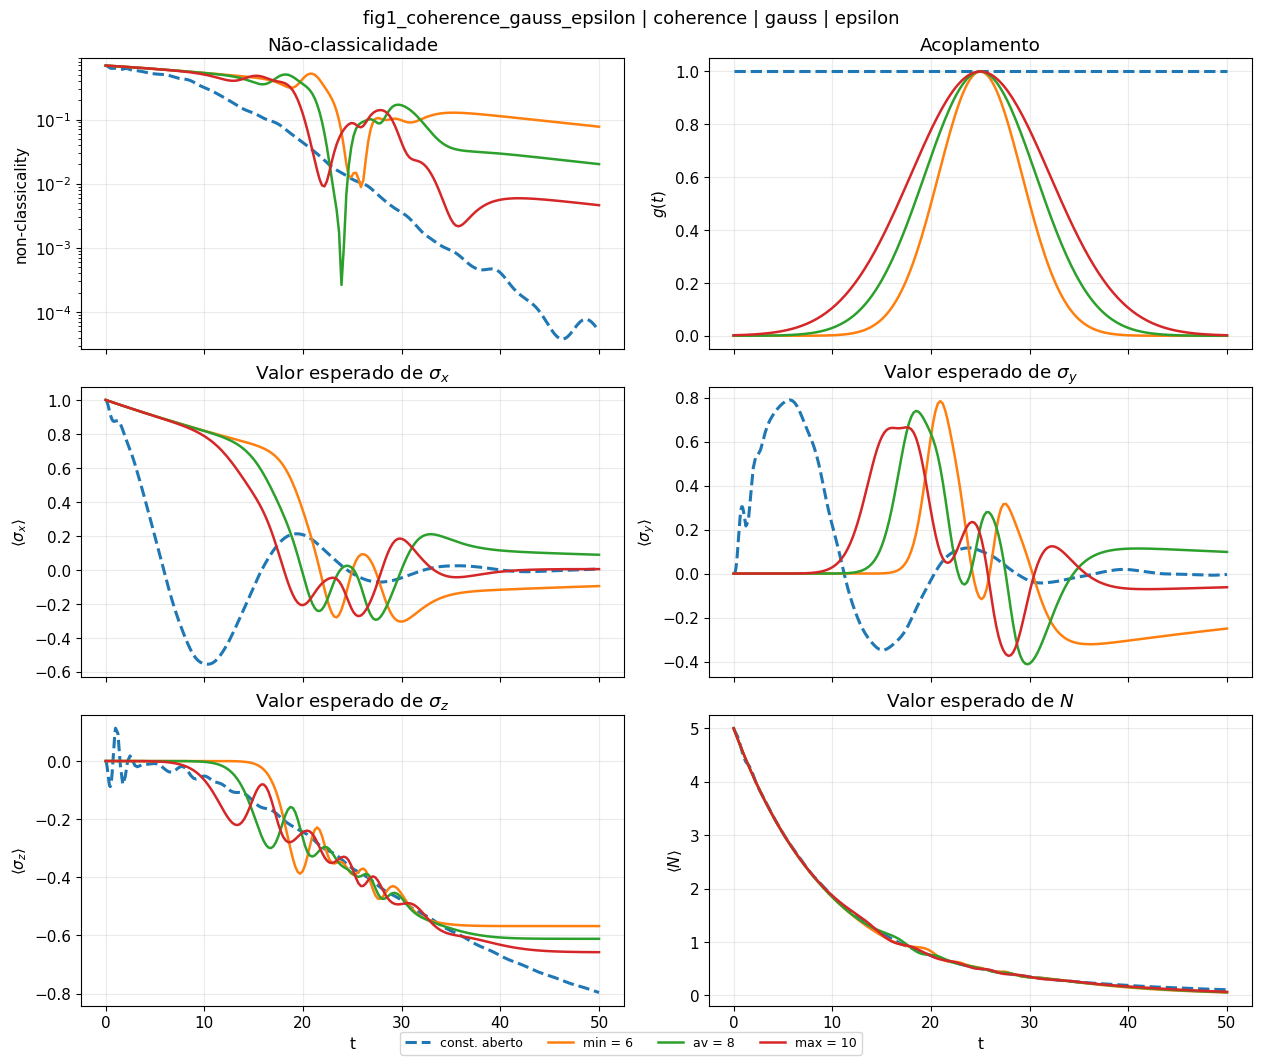

In [7]:
plot_case_3x2_sigma_separated(case_id, save=False)


## Tabela-resumo do caso


In [8]:

show_summary(case_id)


,label,case_id,scan_name,scan_value,display_value,expect_X_initial,expect_X_final,expect_X_min,expect_X_max,expect_X_mean,...,expect_N2_initial,expect_N2_final,expect_N2_min,expect_N2_max,expect_N2_mean,var_N_initial,var_N_final,var_N_min,var_N_max,var_N_mean
0,const_aberto,fig1_coherence_gauss_epsilon,const,NaN,NaN,1.0,0.004804,-0.555390,1.0,0.307673,...,30.0,0.111962,0.111962,30.000000,11.480839,5.0,0.100469,0.100469,5.397146,2.433482
1,const,fig1_coherence_gauss_epsilon,const,NaN,NaN,1.0,-0.197366,-0.754111,1.0,0.296065,...,30.0,30.130543,29.859269,31.097129,30.508854,5.0,5.501796,5.000000,5.718159,5.475144
2,var_aberto_min,fig1_coherence_gauss_epsilon,epsilon,6.0,6.0,1.0,-0.095388,-0.303973,1.0,0.488705,...,30.0,0.057485,0.057485,30.000000,11.251106,5.0,0.054448,0.054448,5.000000,2.243653
3,var_min,fig1_coherence_gauss_epsilon,epsilon,6.0,6.0,1.0,-0.576570,-0.576570,1.0,0.475301,...,30.0,30.527189,29.840223,31.093966,30.239963,5.0,5.453054,5.000000,5.717150,5.225180
4,var_aberto_av,fig1_coherence_gauss_epsilon,epsilon,8.0,8.0,1.0,0.088882,-0.293859,1.0,0.532993,...,30.0,0.062797,0.062797,30.000000,11.264276,5.0,0.059222,0.059222,5.000000,2.251529
5,var_av,fig1_coherence_gauss_epsilon,epsilon,8.0,8.0,1.0,-0.756676,-0.756676,1.0,0.381445,...,30.0,30.434759,29.836315,31.096655,30.261789,5.0,5.549720,5.000000,5.716800,5.265372
6,var_aberto_max,fig1_coherence_gauss_epsilon,epsilon,10.0,10.0,1.0,0.004551,-0.272315,1.0,0.480043,...,30.0,0.071105,0.071105,30.000000,11.278995,5.0,0.066498,0.066498,5.000000,2.261111
7,var_max,fig1_coherence_gauss_epsilon,epsilon,10.0,10.0,1.0,-0.495038,-0.756364,1.0,0.381281,...,30.0,30.130521,29.834229,31.097008,30.276915,5.0,5.311282,5.000000,5.718398,5.270657



## Plotar todos os casos

Se quiser salvar as figuras automaticamente nas respectivas pastas de cada caso, mude `SAVE_ALL = True`.


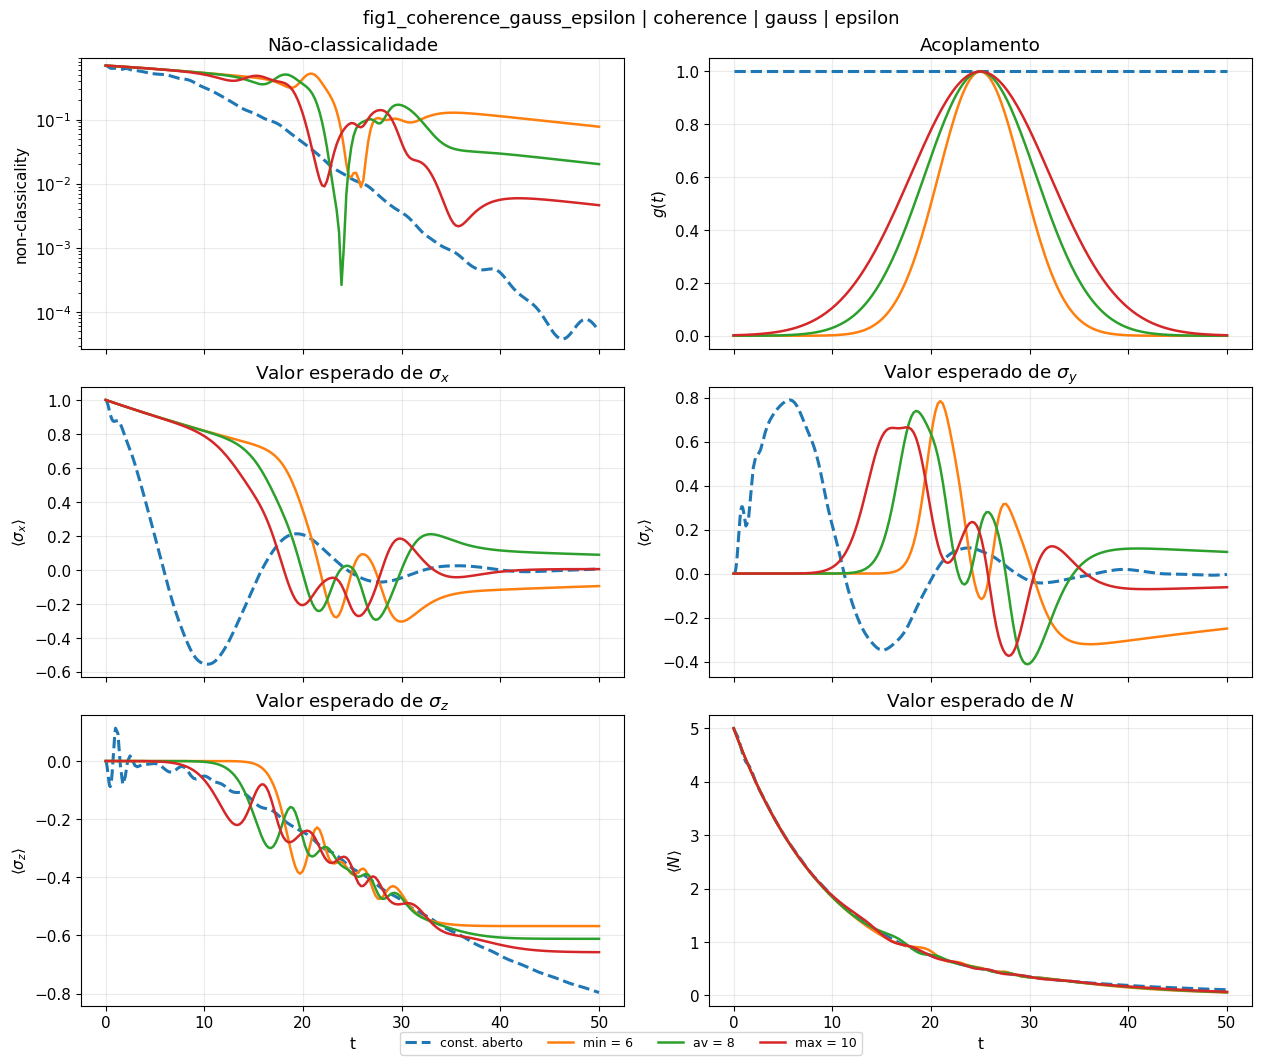

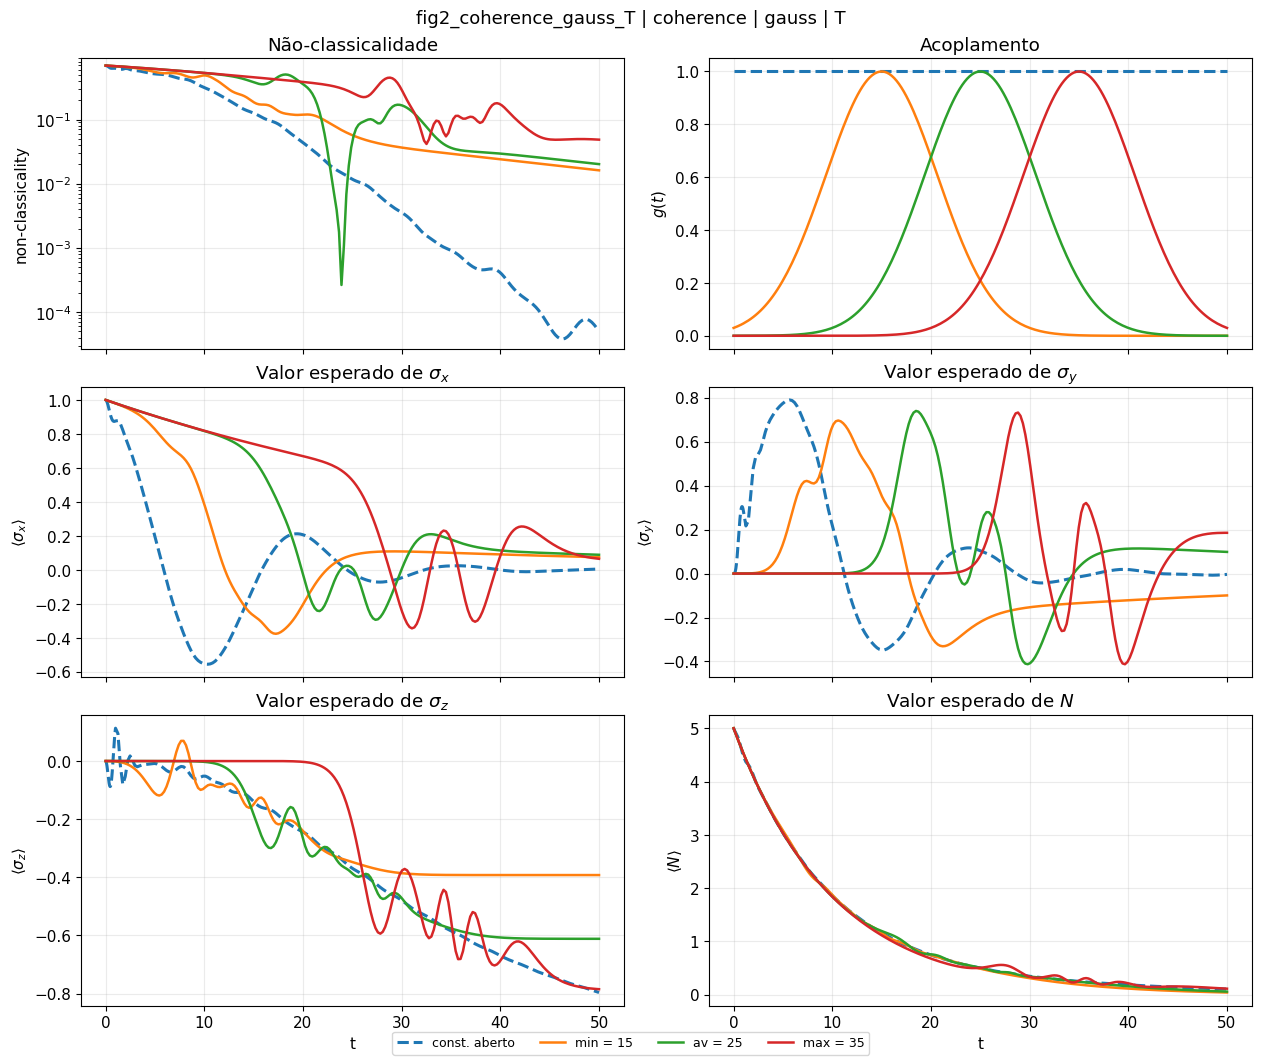

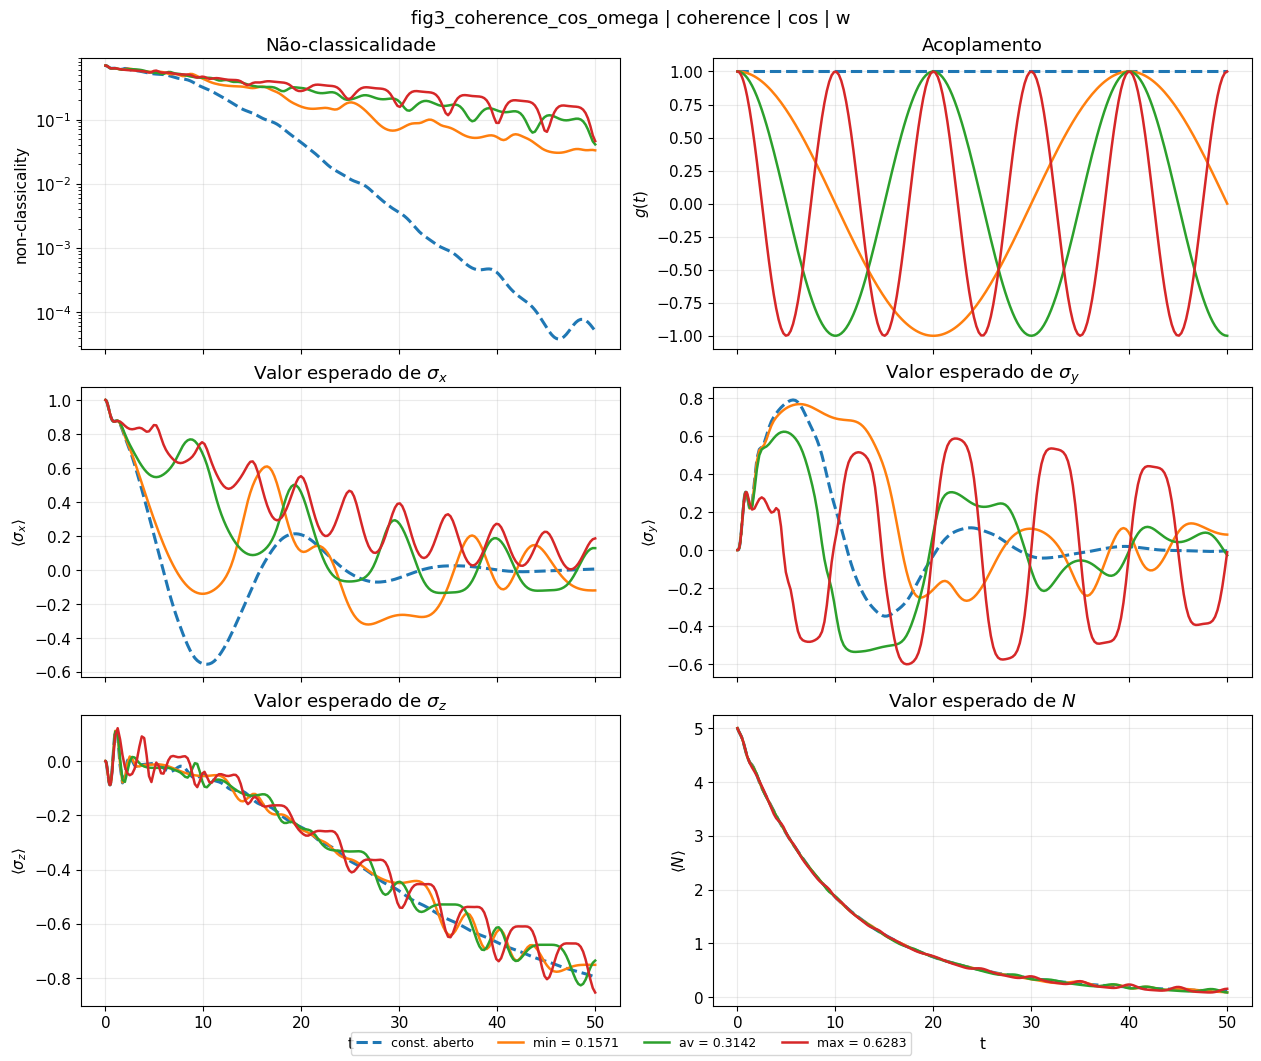

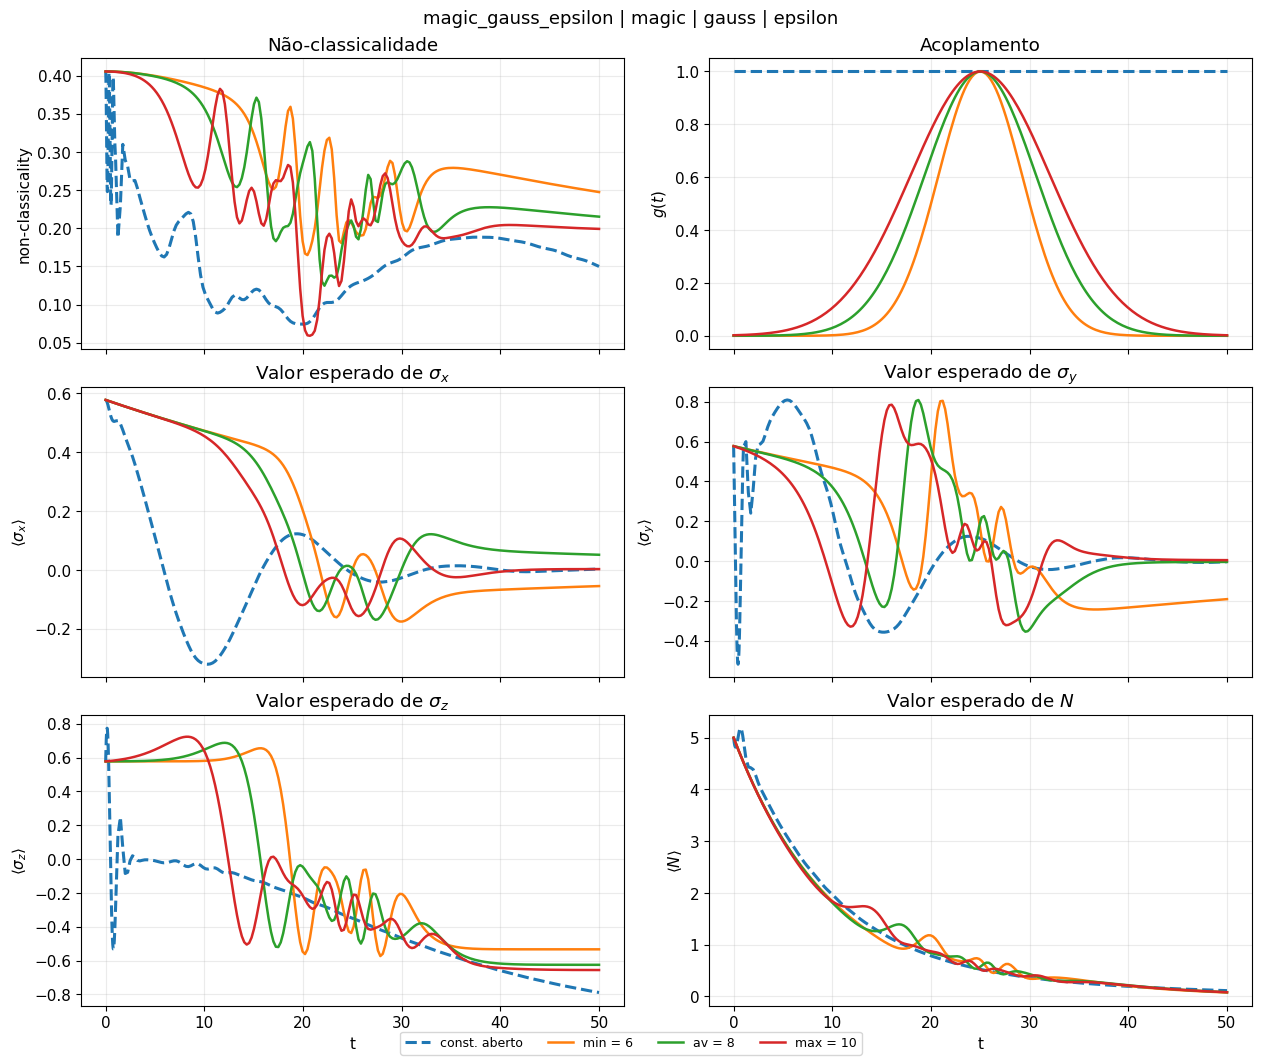

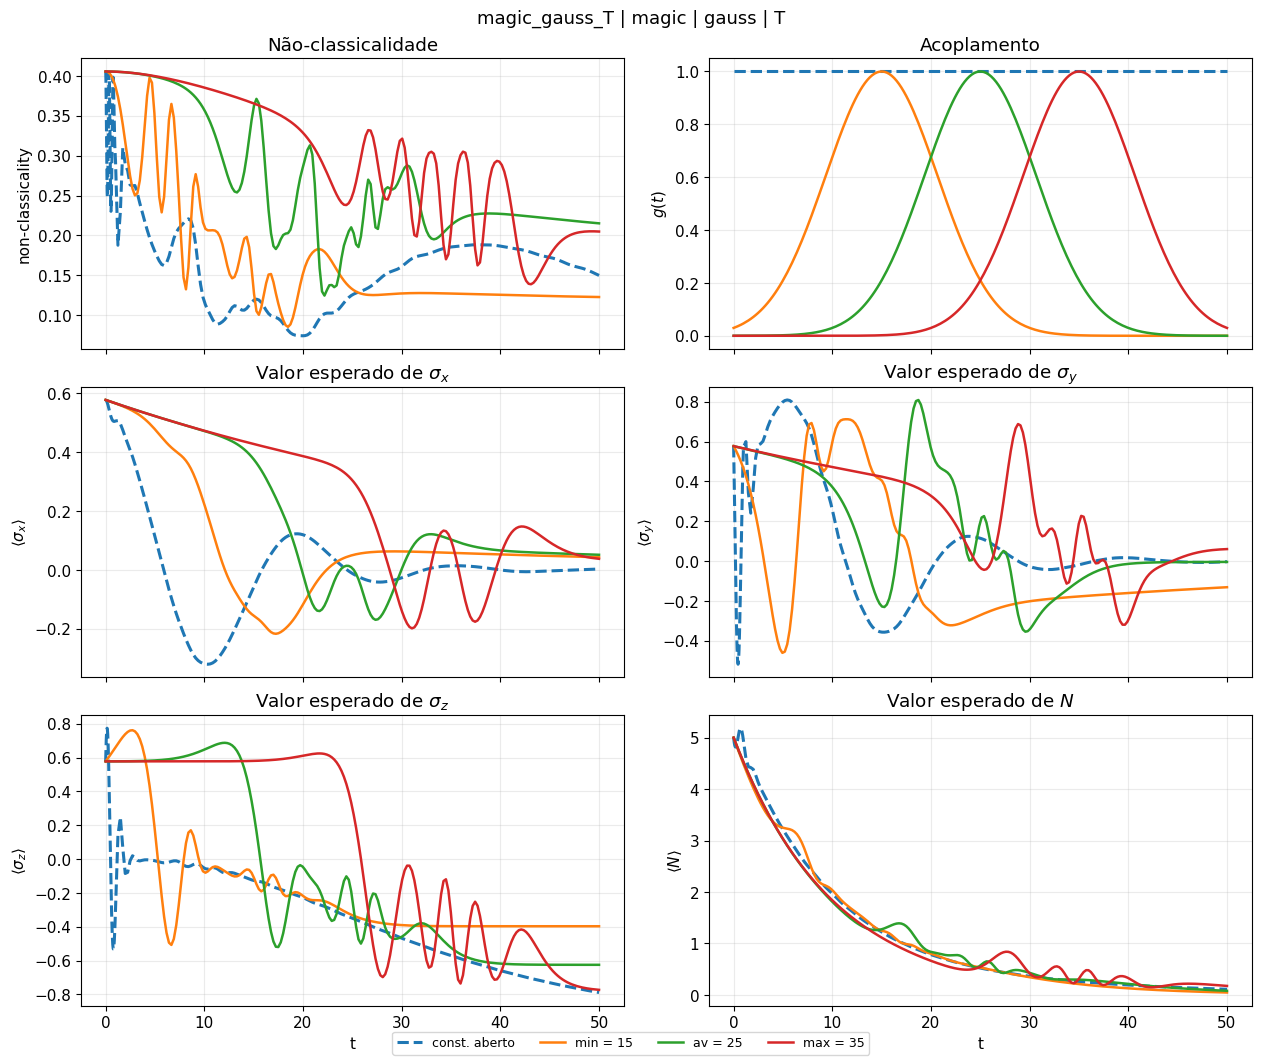

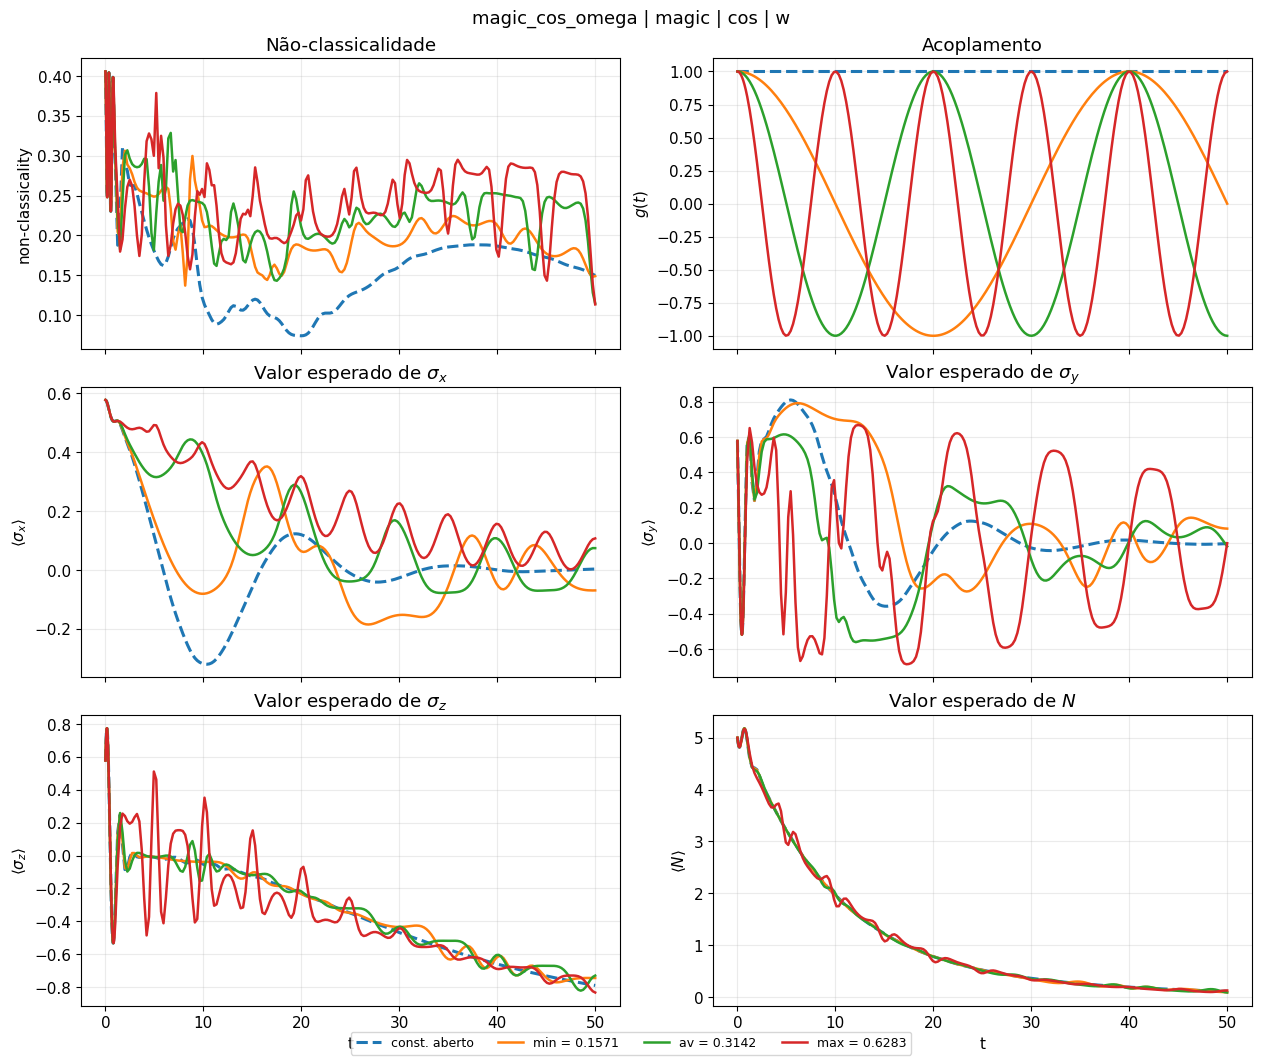

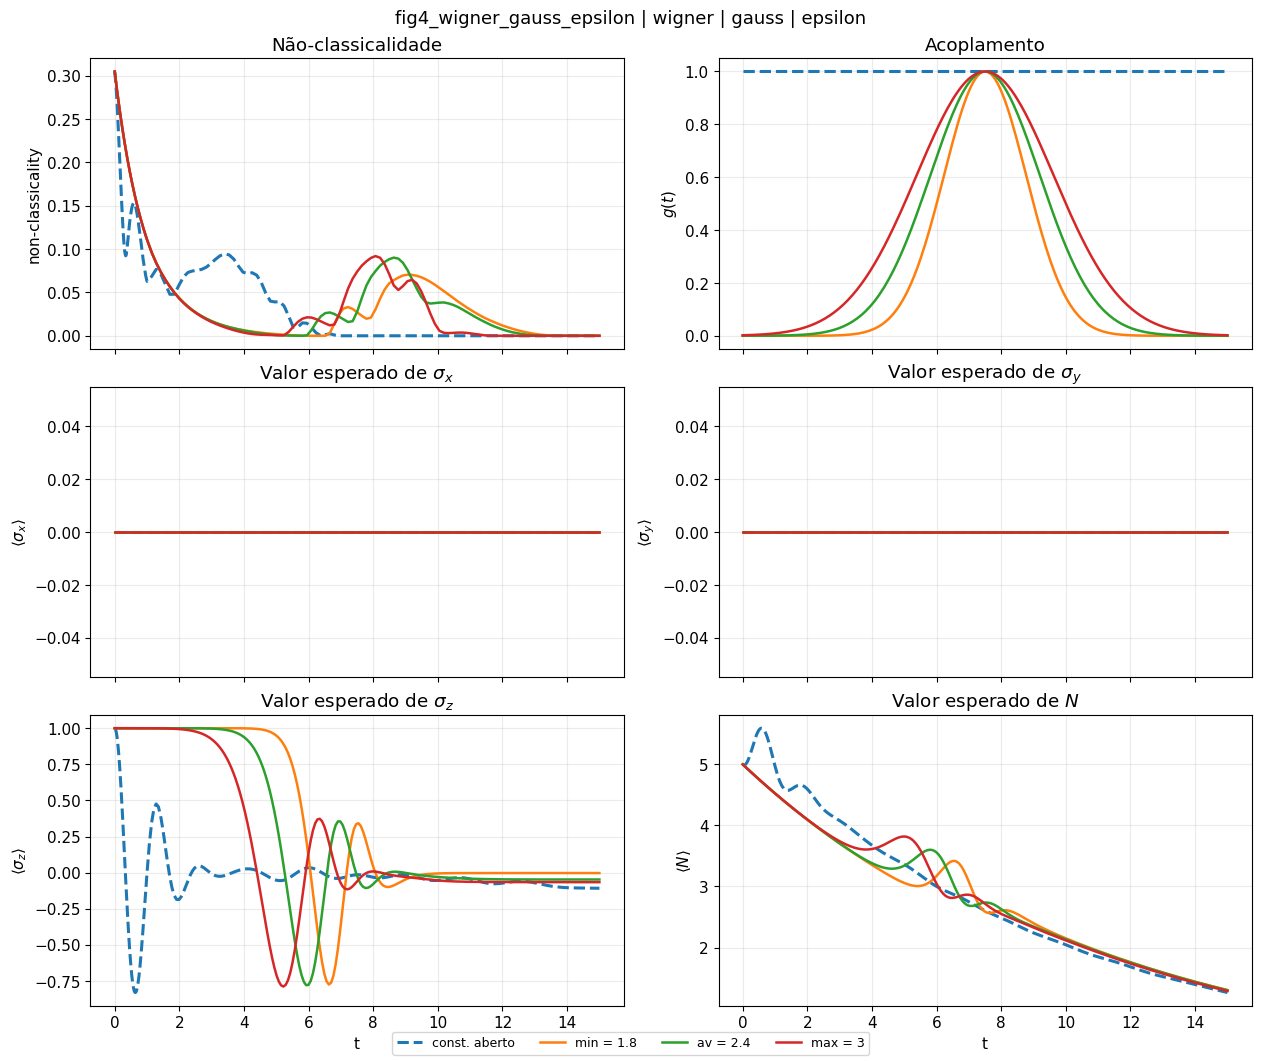

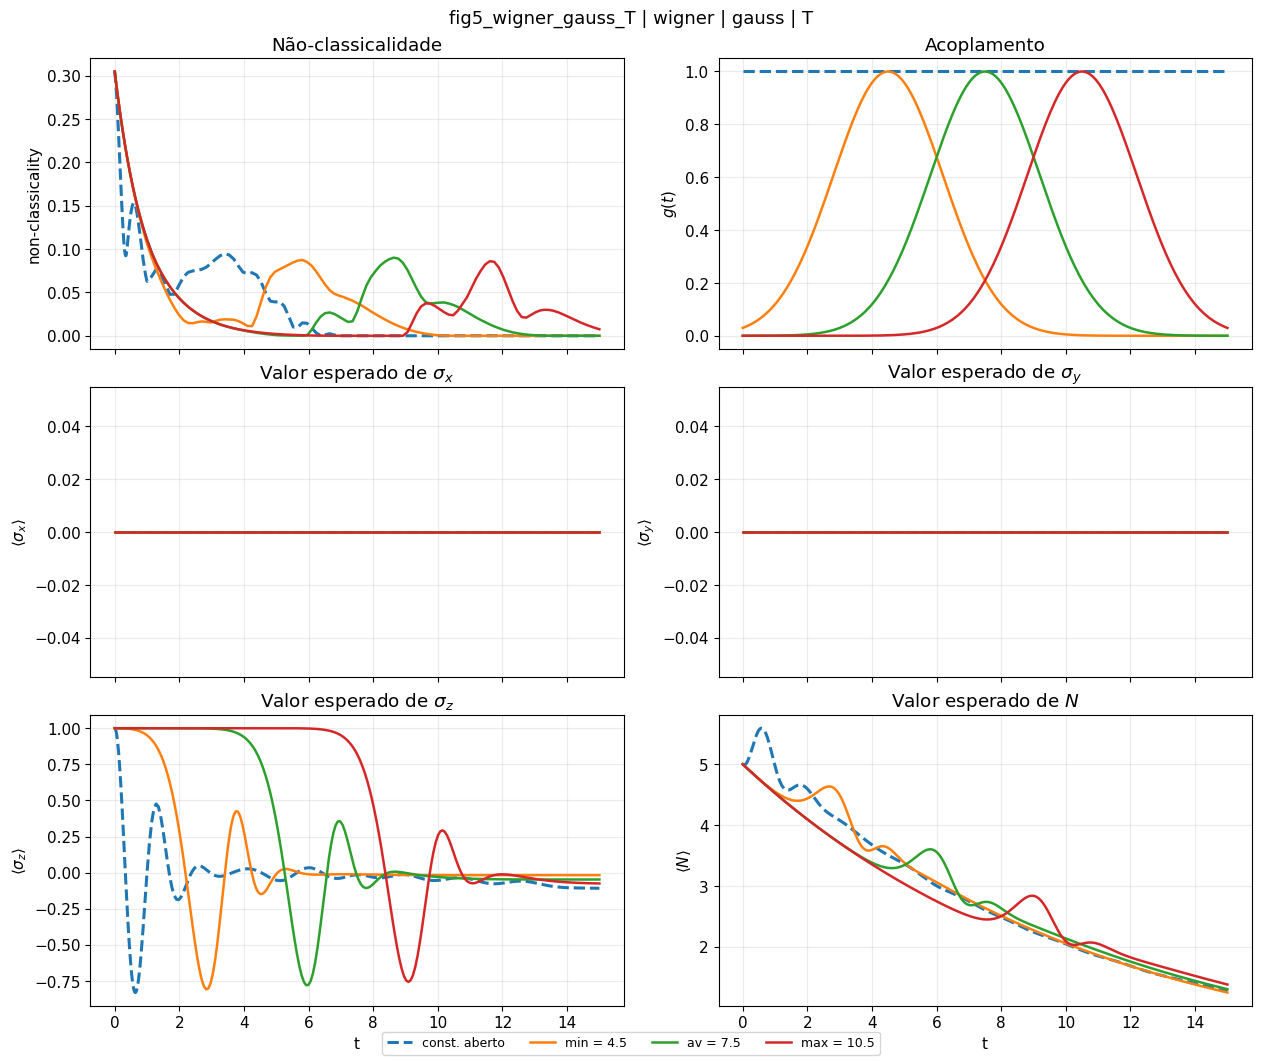

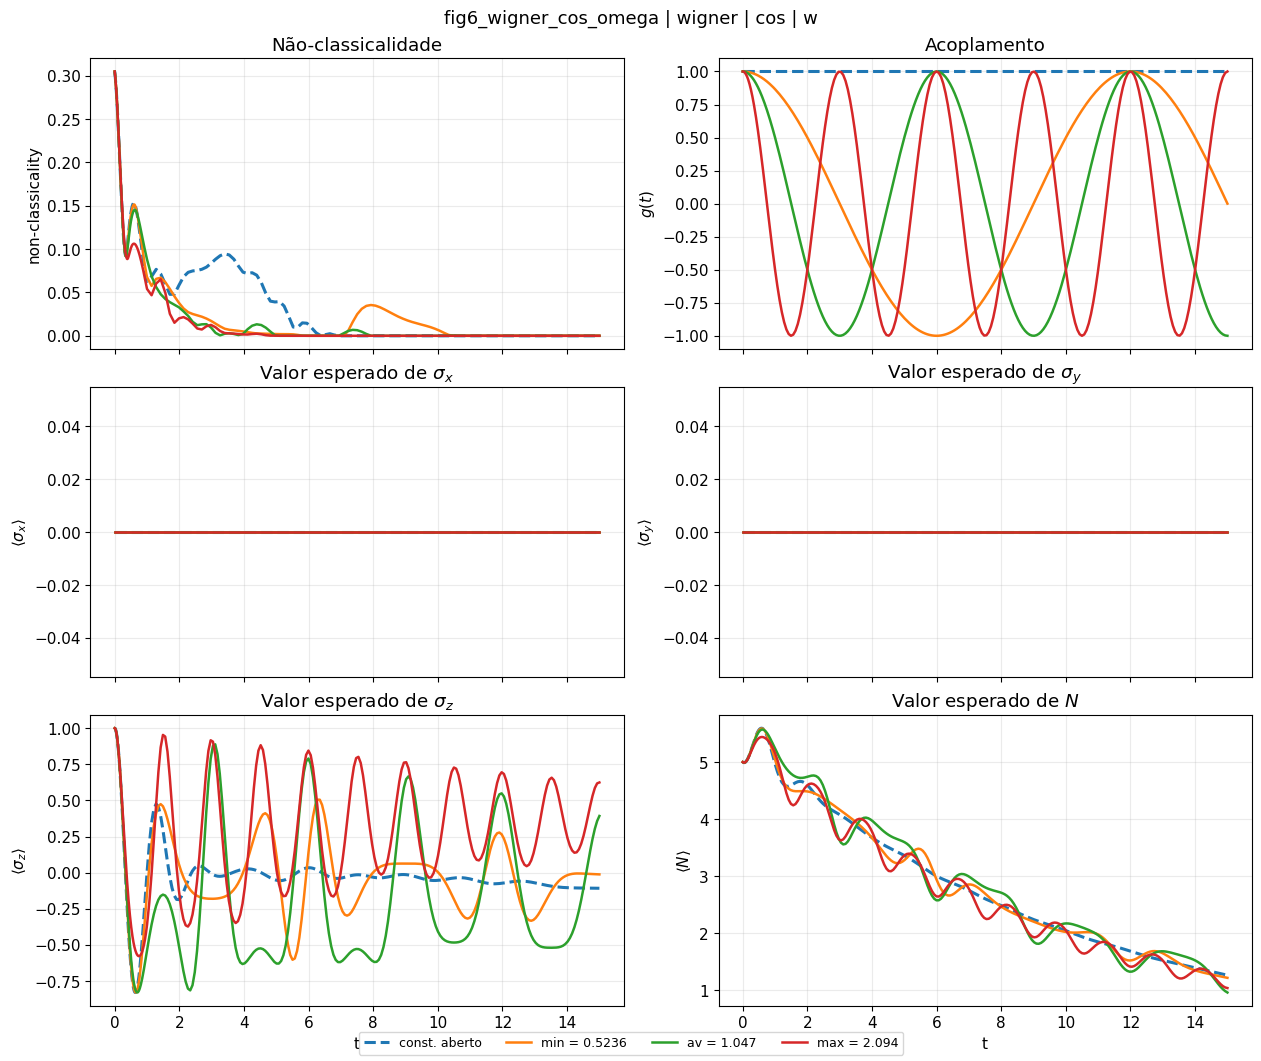

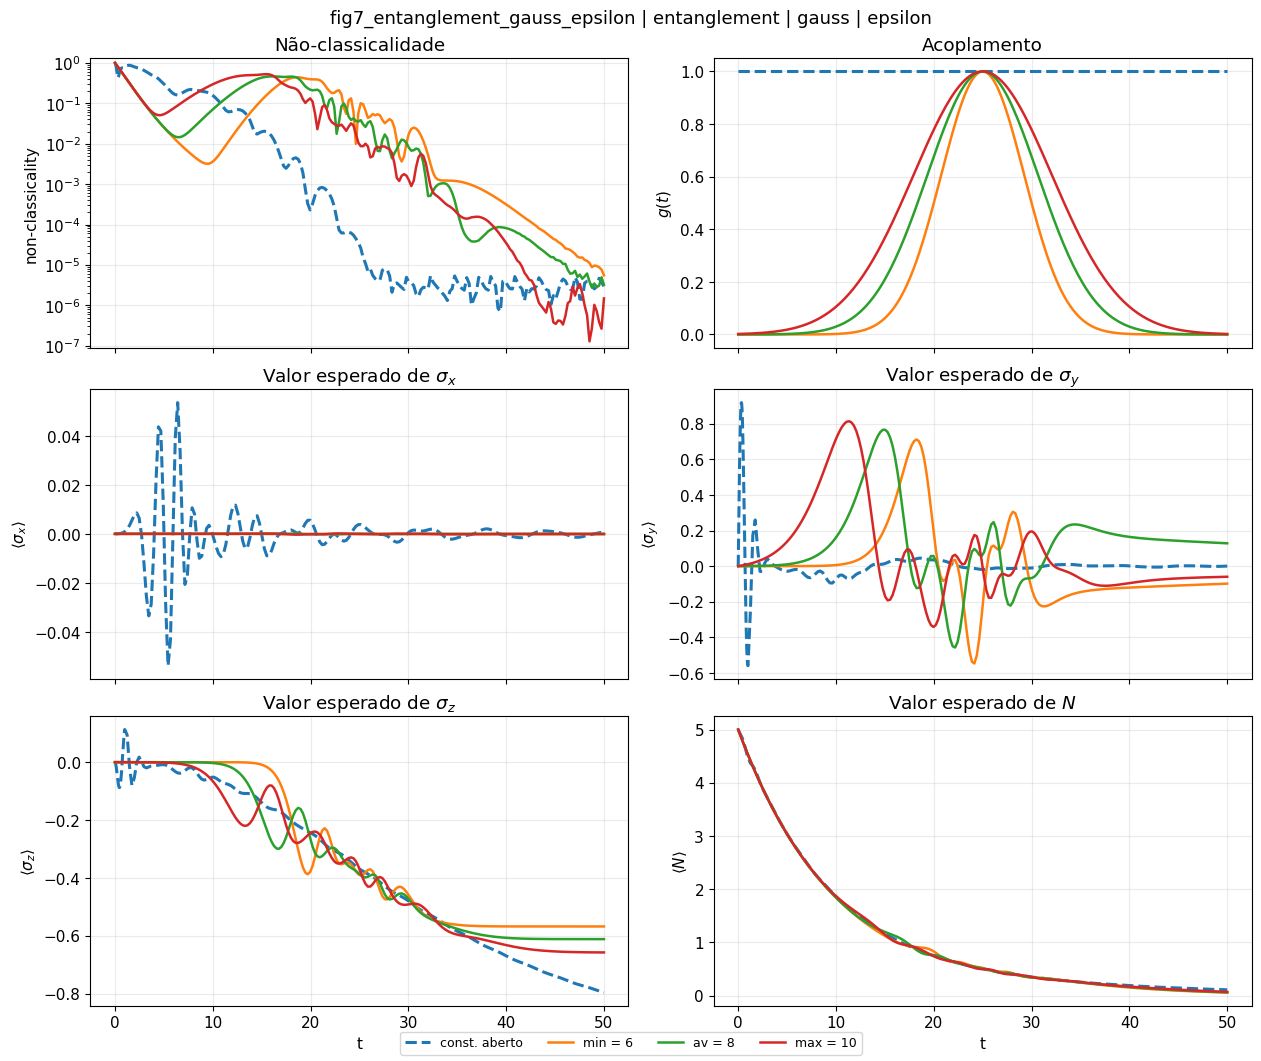

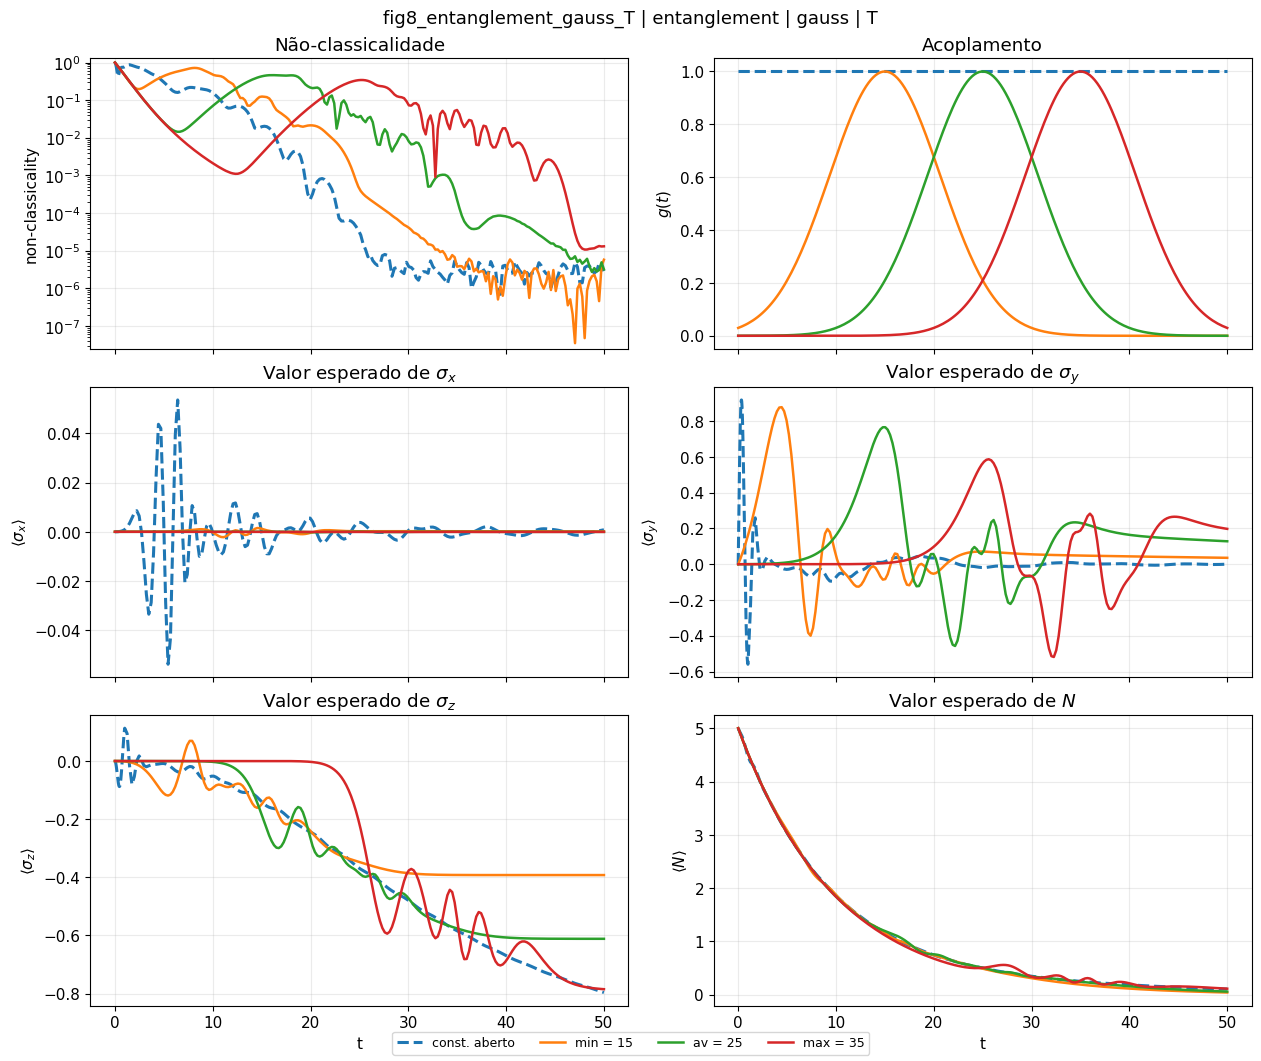

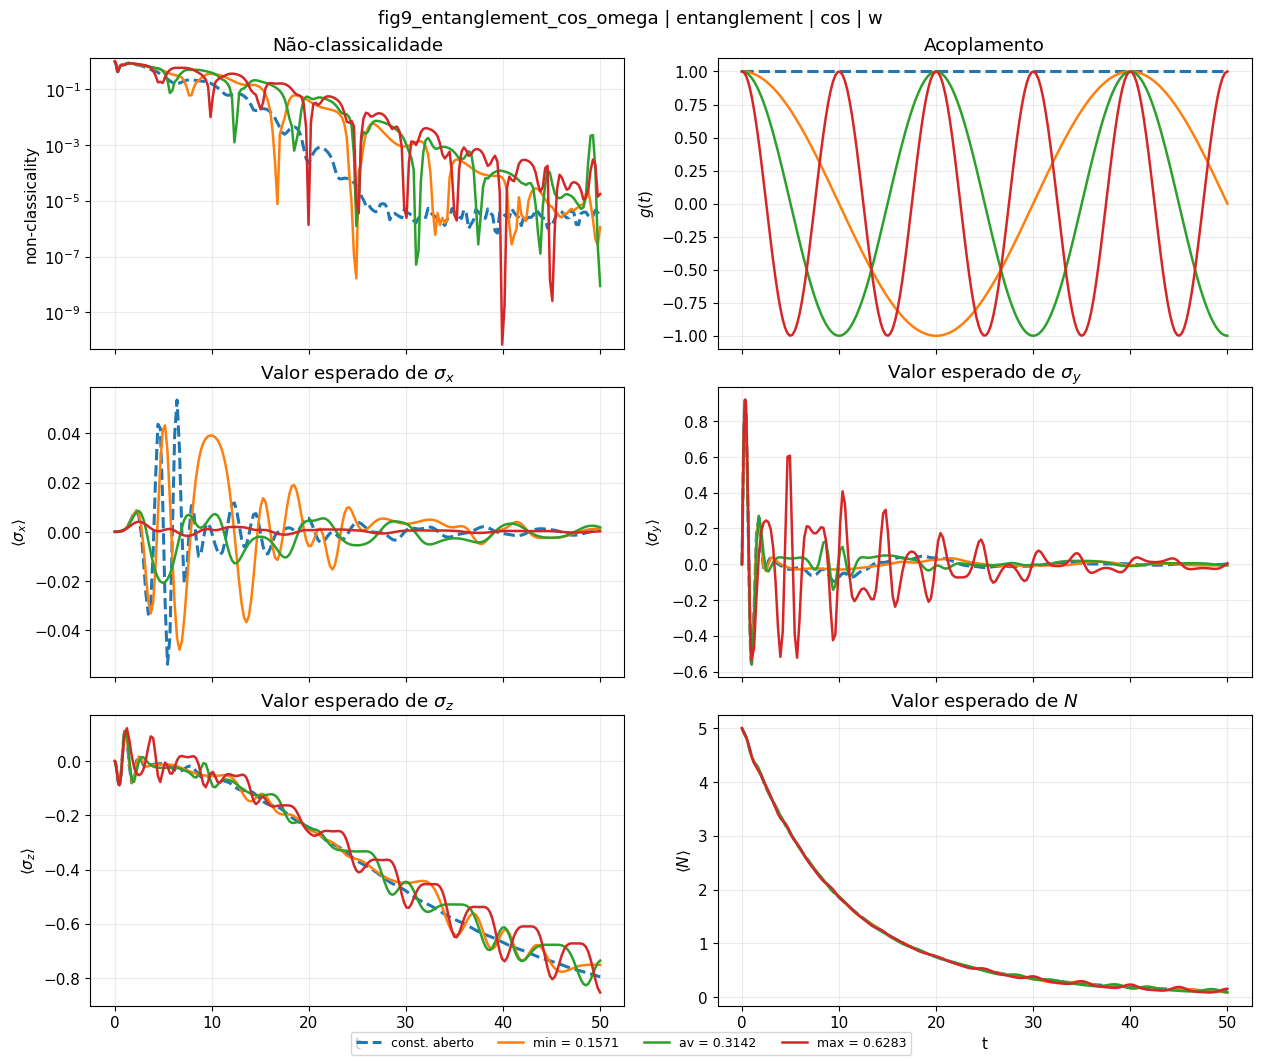

In [9]:
SAVE_ALL = False

for cid in case_map["case_id"].tolist():
    plot_case_3x2_sigma_separated(cid, save=SAVE_ALL)